In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("plots.mplstyle")

# Pulsed ODMR: tau_scan_7 onwards

Each `tau_scan_N` folder holds one or more `tau{tau_mw_us}us_power{drive_power_dbm}dBm` runs. A run only counts as completed if it has an `avg` fileset (a run that crashed after only a `repeat0` never got its average written) and its frequency sweep is the full length (a run interrupted partway through still writes an `avg` over however many points it reached, so a short sweep is excluded too) -- both checked automatically.

In [2]:
PULSED_ODMR_DIR = Path(r"D:\pulsed_odmr")
MIN_SCAN_NUM = 7


def parse_metadata(path):
    metadata = {}
    for line in open(path):
        key, _, value = line.strip().partition("=")
        metadata[key] = value
    return metadata


def discover_completed_runs(base_dir, min_scan_num=MIN_SCAN_NUM):
    """Find every completed tau_scan_N run, N >= min_scan_num: must have an
    avg fileset (a run that crashed after only a repeat0 never got its
    average written) AND a full-length frequency sweep (a run interrupted
    partway through still writes an avg over however many points it got
    to, so a short sweep isn't itself proof of an incomplete run -- checked
    against the most common sweep length across all avg filesets found).
    Returns a list of {"folder", "prefix", "tau_mw_us", "power_dbm", "scan_num"} dicts.
    """
    candidates = []
    for folder in sorted(base_dir.glob("tau_scan_*")):
        try:
            scan_num = int(folder.name.rsplit("_", 1)[-1])
        except ValueError:
            continue
        if scan_num < min_scan_num:
            continue
        for meta_file in sorted(folder.glob("*_avg_pulsed_odmr_metadata.txt")):
            metadata = parse_metadata(meta_file)
            prefix = meta_file.name[: -len("_metadata.txt")]
            n_points = len(np.load(folder / f"{prefix}_freqs_hz.npy"))
            candidates.append({
                "folder": folder,
                "prefix": prefix,
                "tau_mw_us": float(metadata["tau_mw_us"]),
                "power_dbm": float(metadata["drive_power_dbm"]),
                "scan_num": scan_num,
                "n_points": n_points,
            })

    point_counts = [run["n_points"] for run in candidates]
    full_length = max(set(point_counts), key=point_counts.count)
    runs, dropped = [], []
    for run in candidates:
        (runs if run["n_points"] == full_length else dropped).append(run)
    if dropped:
        print(f"excluded {len(dropped)} truncated run(s) (expected {full_length} points):")
        for run in dropped:
            print(f"  {run['folder'].name}/{run['prefix']}: only {run['n_points']} points")
    return runs


def load_run_spectrum(run):
    freqs_hz = np.load(run["folder"] / f"{run['prefix']}_freqs_hz.npy")
    x = np.load(run["folder"] / f"{run['prefix']}_x.npy")
    y = np.load(run["folder"] / f"{run['prefix']}_y.npy")
    return freqs_hz, np.hypot(x, y)


runs = discover_completed_runs(PULSED_ODMR_DIR)
print(f"\n{len(runs)} completed runs:")
for run in runs:
    print(f"  {run['folder'].name}: tau={run['tau_mw_us']:g} us, power={run['power_dbm']:g} dBm")

excluded 8 truncated run(s) (expected 601 points):
  tau_scan_11/tau_scan_11_tau0p5us_powerm15dBm_avg_pulsed_odmr: only 21 points
  tau_scan_15/tau_scan_15_tau16us_power0dBm_avg_pulsed_odmr: only 215 points
  tau_scan_15/tau_scan_15_tau1us_power0dBm_avg_pulsed_odmr: only 410 points
  tau_scan_15/tau_scan_15_tau2us_power0dBm_avg_pulsed_odmr: only 250 points
  tau_scan_15/tau_scan_15_tau32us_power0dBm_avg_pulsed_odmr: only 215 points
  tau_scan_15/tau_scan_15_tau4us_power0dBm_avg_pulsed_odmr: only 225 points
  tau_scan_15/tau_scan_15_tau8us_power0dBm_avg_pulsed_odmr: only 230 points
  tau_scan_9/tau_scan_9_tau0p5us_powerm25dBm_avg_pulsed_odmr: only 50 points

52 completed runs:
  tau_scan_10: tau=0.5 us, power=-35 dBm
  tau_scan_10: tau=0.5 us, power=-40 dBm
  tau_scan_11: tau=0.5 us, power=-25 dBm
  tau_scan_12: tau=8 us, power=-25 dBm
  tau_scan_13: tau=0.1 us, power=-25 dBm
  tau_scan_13: tau=0.2 us, power=-25 dBm
  tau_scan_13: tau=0.4 us, power=-25 dBm
  tau_scan_14: tau=0.13 us, po

In [3]:
from scipy.optimize import curve_fit


def lorentzian(f, amp, center, width):
    return amp * width**2 / ((f - center) ** 2 + width**2)


def double_lorentzian(f, offset, amp1, center1, width1, amp2, center2, width2):
    return (
        offset
        + lorentzian(f, amp1, center1, width1)
        + lorentzian(f, amp2, center2, width2)
    )


def fit_double_lorentzian(freqs_mhz, y, peak_gap_mhz=9.0):
    """Fit y(freqs_mhz) to a constant offset plus two Lorentzians. Returns popt.

    Initial peak centers are placed peak_gap_mhz apart around the weighted
    centroid of y (weighted by height above the median). Widths are bounded
    away from 0 so noise can't get fit as a degenerate spike.
    """
    f_min, f_max = freqs_mhz.min(), freqs_mhz.max()
    f_range = f_max - f_min

    offset0 = np.median(y)
    weights = np.clip(y - offset0, 0, None)
    if weights.sum() > 0:
        centroid = np.average(freqs_mhz, weights=weights)
    else:
        centroid = np.median(freqs_mhz)
    amp0 = np.min(y) - np.max(y)
    width0 = f_range / 10
    center1_0 = np.clip(centroid - peak_gap_mhz / 2, f_min, f_max)
    center2_0 = np.clip(centroid + peak_gap_mhz / 2, f_min, f_max)
    p0 = [offset0, amp0, center1_0, width0, amp0, center2_0, width0]
    bounds = (
        [-np.inf, -np.inf, f_min, 1.0, -np.inf, f_min, 1.0],
        [np.inf, np.inf, f_max, f_range, np.inf, f_max, f_range],
    )
    popt, _ = curve_fit(
        double_lorentzian, freqs_mhz, y, p0=p0, bounds=bounds, maxfev=20000
    )
    return popt

## tau_mw = 0.5 us, various powers

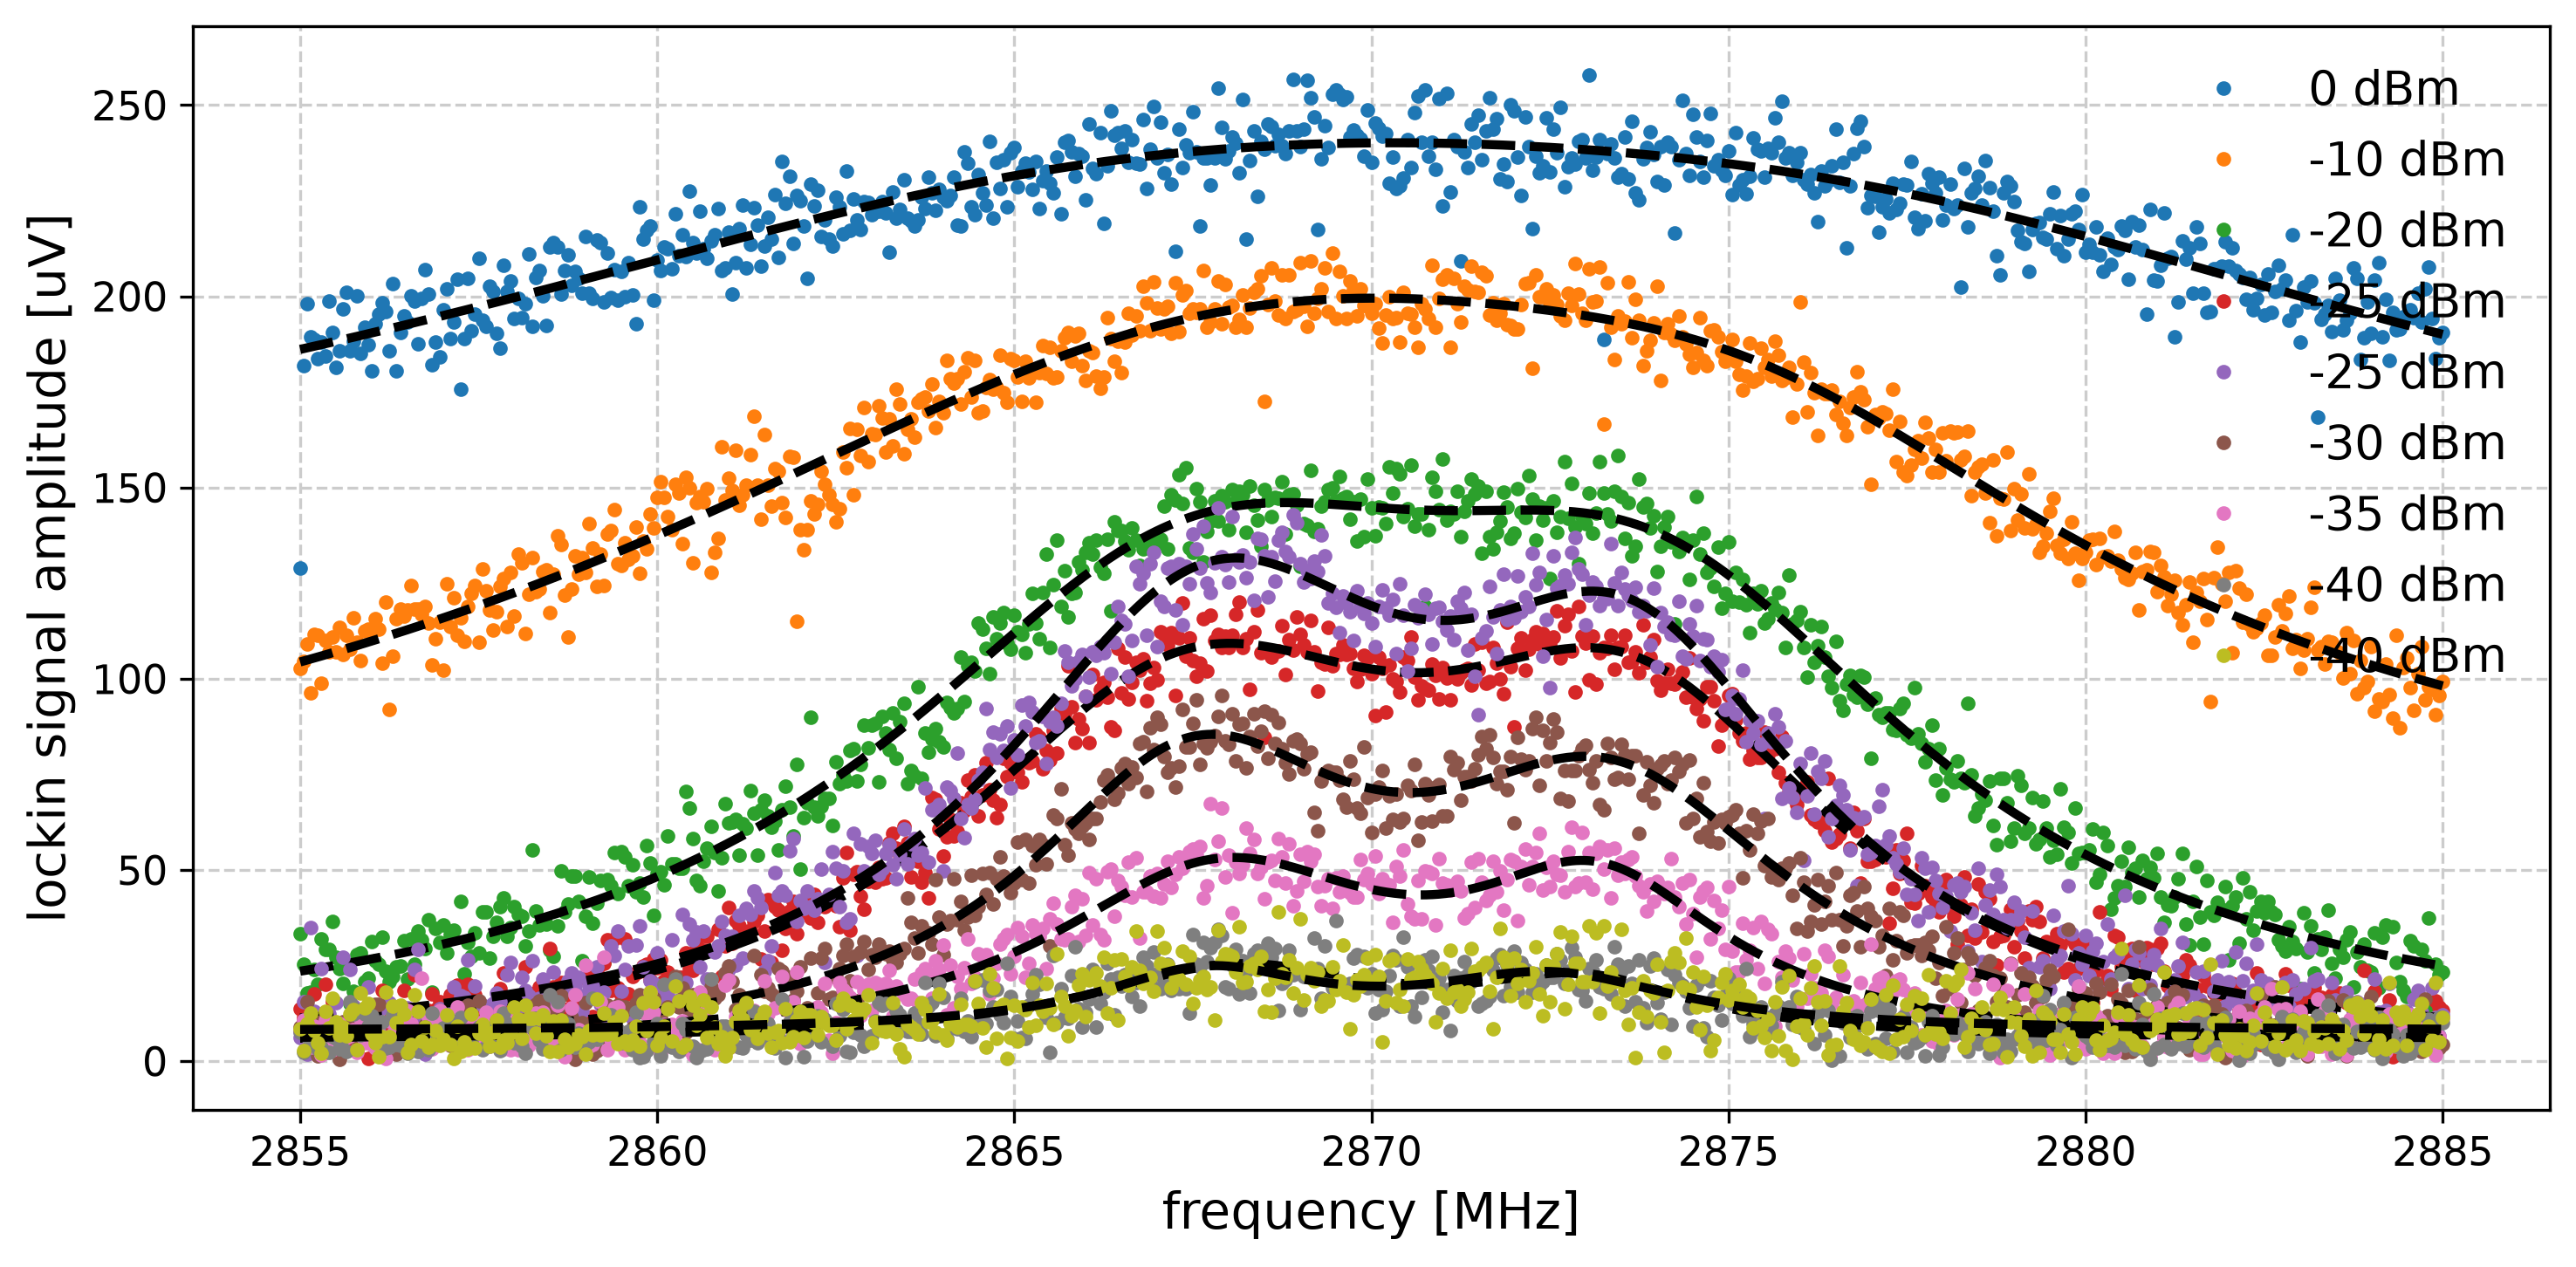

         label  FWHM 1 [MHz]  FWHM 2 [MHz]
         0 dBm        27.837        22.677
       -10 dBm        22.400        10.671
       -20 dBm        10.877         9.586
       -25 dBm         8.224         7.243
       -25 dBm         7.433         6.299
       -30 dBm         5.774         6.366
       -35 dBm         5.876         4.463
       -40 dBm         5.126         3.780
       -40 dBm         3.722         4.438


In [4]:
def plot_runs_with_fits(ax, runs, label_fn):
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    fits = []
    for run, color in zip(runs, itertools.cycle(colors)):
        freqs_hz, r = load_run_spectrum(run)
        freqs_mhz = freqs_hz / 1e6
        r_uv = r * 1e6
        ax.plot(freqs_mhz, r_uv, "o", markersize=3, color=color, label=label_fn(run))

        popt = fit_double_lorentzian(freqs_mhz, r_uv)
        freqs_dense_mhz = np.linspace(freqs_mhz.min(), freqs_mhz.max(), 1000)
        ax.plot(freqs_dense_mhz, double_lorentzian(freqs_dense_mhz, *popt), "--", color="black")
        fits.append({**run, "popt": popt})
    ax.set_xlabel("frequency [MHz]")
    ax.set_ylabel("lockin signal amplitude [uV]")
    ax.legend()
    return fits


def print_linewidths(fits, label_fn):
    header = f"{'label':>14} {'FWHM 1 [MHz]':>13} {'FWHM 2 [MHz]':>13}"
    print(header)
    for fit in fits:
        _, _, _, width1, _, _, width2 = fit["popt"]
        print(f"{label_fn(fit):>14} {2 * abs(width1):>13.3f} {2 * abs(width2):>13.3f}")


tau_0p5_runs = sorted(
    (run for run in runs if run["tau_mw_us"] == 0.5),
    key=lambda run: run["power_dbm"],
    reverse=True,
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
tau_0p5_fits = plot_runs_with_fits(ax, tau_0p5_runs, lambda run: f"{run['power_dbm']:g} dBm")
fig.tight_layout()
plt.show()

print_linewidths(tau_0p5_fits, lambda run: f"{run['power_dbm']:g} dBm")

## Power vs. contrast

The fitted `offset` isn't a clean flat baseline for this data (curved/sloped
background, worse at high power where the two peaks broaden and overlap), so a
naive `amp / offset` blows up (it did -- values in the thousands of %). Using
`amp / (amp + offset)` instead stays bounded in [0, 100%] regardless, at the
cost of it now meaning "fraction of the on-resonance signal due to the peak"
rather than "fractional change from an off-resonance baseline". Averaged over
the two peaks.

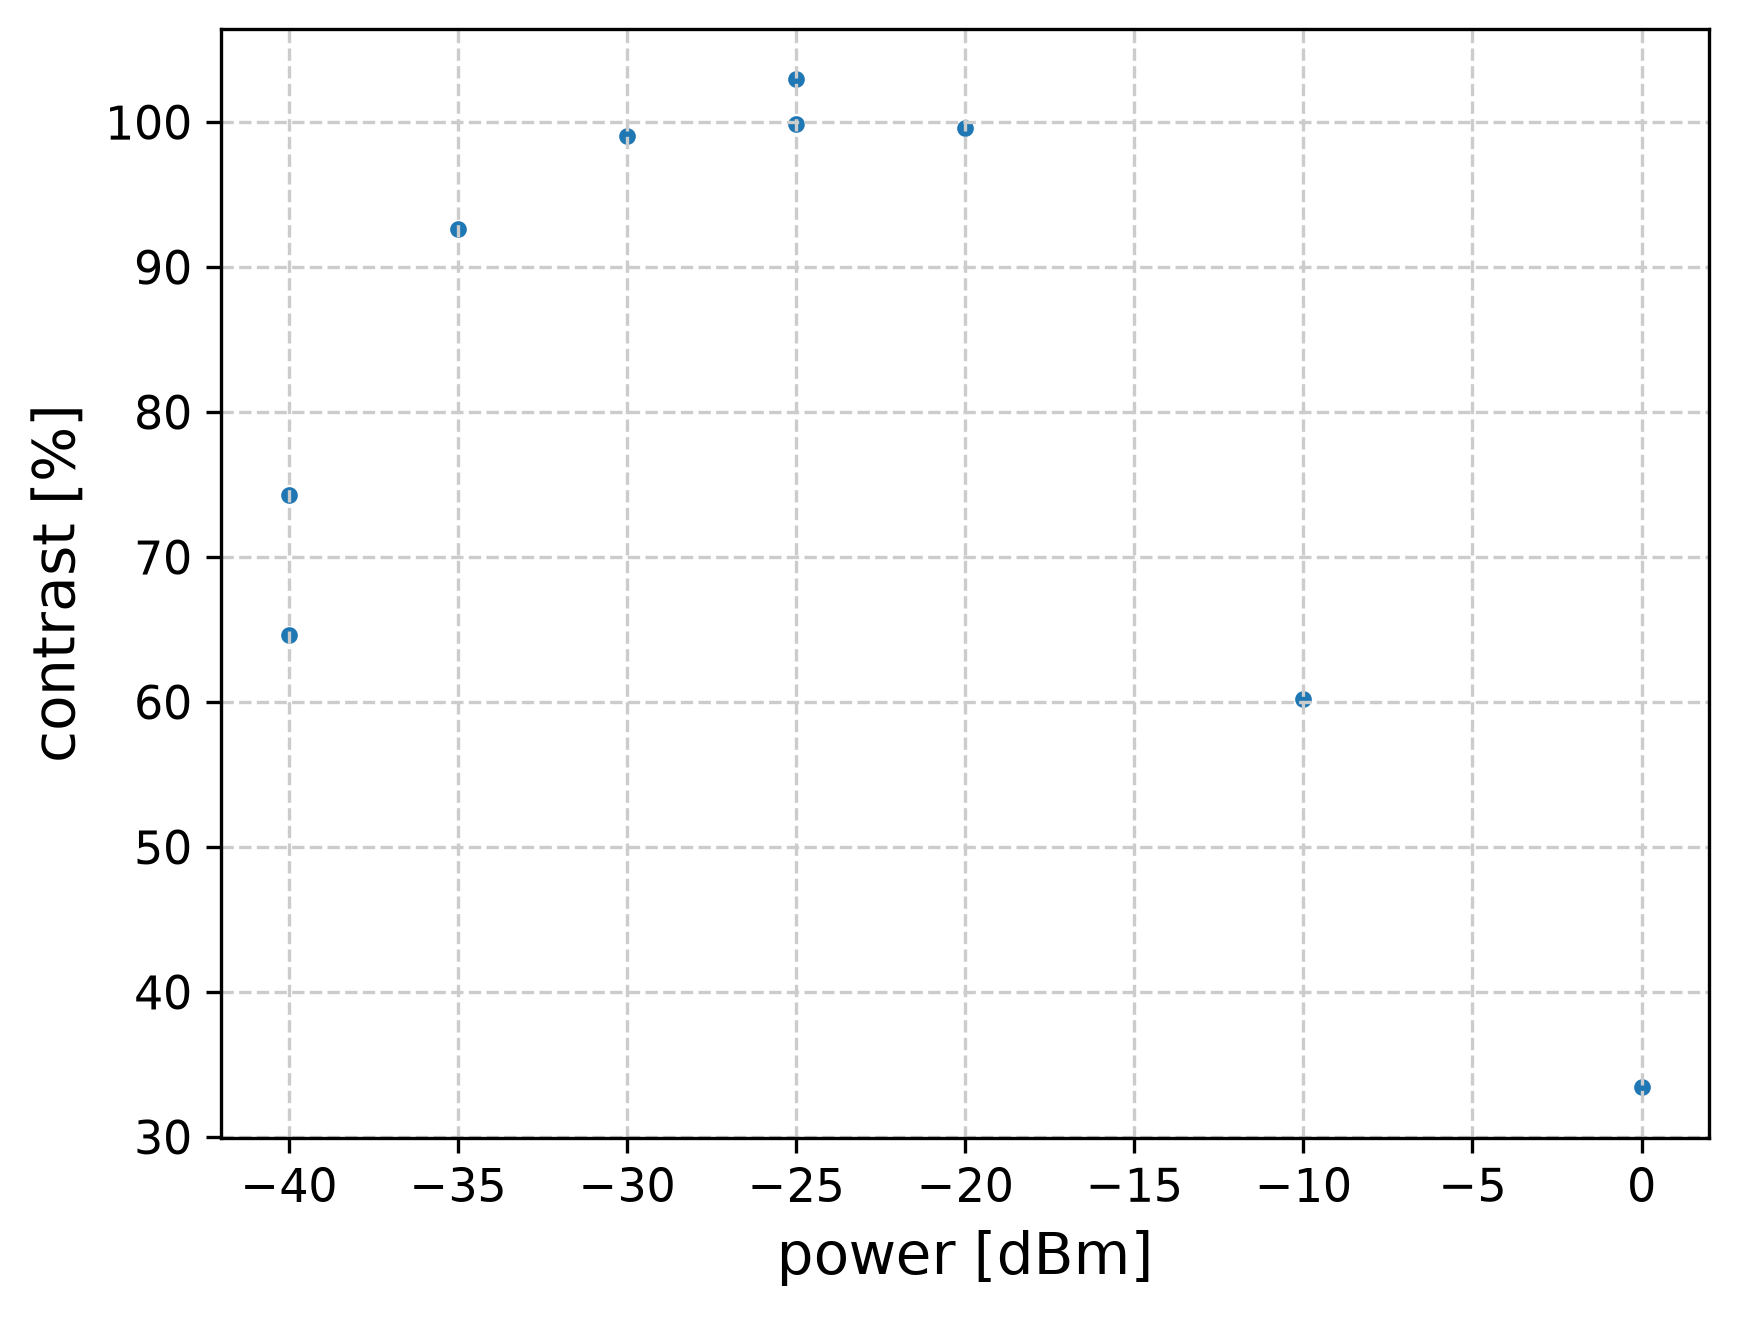

In [5]:
def contrast_pct(popt):
    offset, amp1, _, _, amp2, _, _ = popt
    amp1, amp2 = abs(amp1), abs(amp2)
    return 100 * np.mean([amp1 / (amp1 + offset), amp2 / (amp2 + offset)])


powers_dbm = np.array([fit["power_dbm"] for fit in tau_0p5_fits])
contrasts_pct = np.array([contrast_pct(fit["popt"]) for fit in tau_0p5_fits])

fig, ax = plt.subplots(dpi=300)
ax.scatter(powers_dbm, contrasts_pct)
ax.set_xlabel("power [dBm]")
ax.set_ylabel("contrast [%]")
plt.show()

## Power vs. linewidth

Averaged over the two peaks (mean +/- SEM). The dashed line marks the Fourier
transform-limited linewidth for this tau_mw_us = 0.5 us pulse, 0.8 / tau_mw_us.

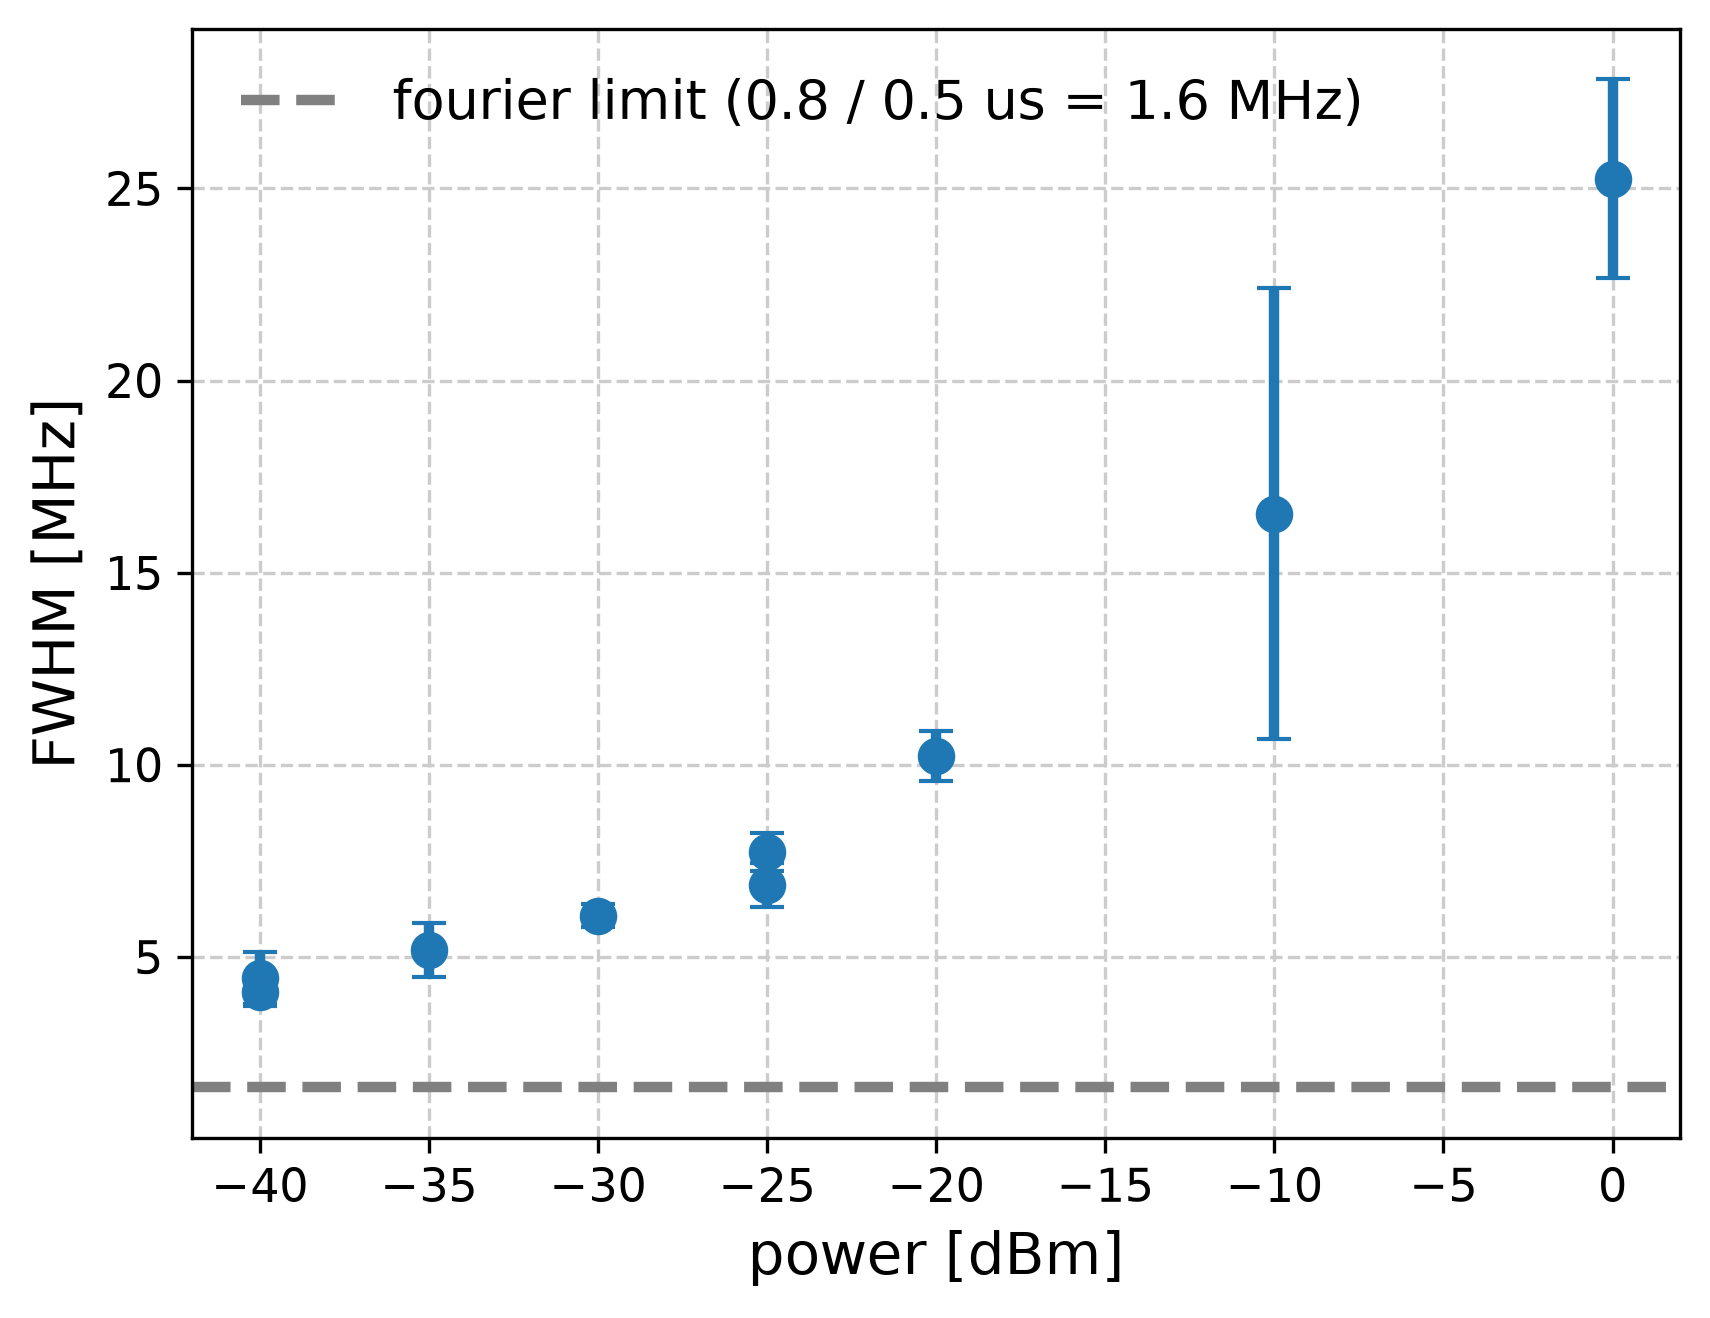

In [6]:
def mean_and_sem(values, axis=None):
    values = np.asarray(values)
    n = values.shape[axis] if axis is not None else values.size
    mean = np.mean(values, axis=axis)
    sem = np.std(values, axis=axis, ddof=1) / np.sqrt(n)
    return mean, sem


TAU_MW_US = 0.5
FOURIER_LIMIT_MHZ = 0.8 / TAU_MW_US

fwhm_pairs = np.array(
    [[2 * abs(fit["popt"][3]), 2 * abs(fit["popt"][6])] for fit in tau_0p5_fits]
)
fwhm_mean, fwhm_sem = mean_and_sem(fwhm_pairs, axis=1)

fig, ax = plt.subplots(dpi=300)
ax.errorbar(powers_dbm, fwhm_mean, yerr=fwhm_sem, fmt="o", markersize=8, capsize=4)
ax.axhline(
    FOURIER_LIMIT_MHZ, linestyle="--", color="gray",
    label=f"fourier limit (0.8 / {TAU_MW_US:g} us = {FOURIER_LIMIT_MHZ:.1f} MHz)",
)
ax.set_xlabel("power [dBm]")
ax.set_ylabel("FWHM [MHz]")
ax.legend()
plt.show()

## Power vs. max signal

Peak height (offset + amplitude) for each of the two fitted peaks.

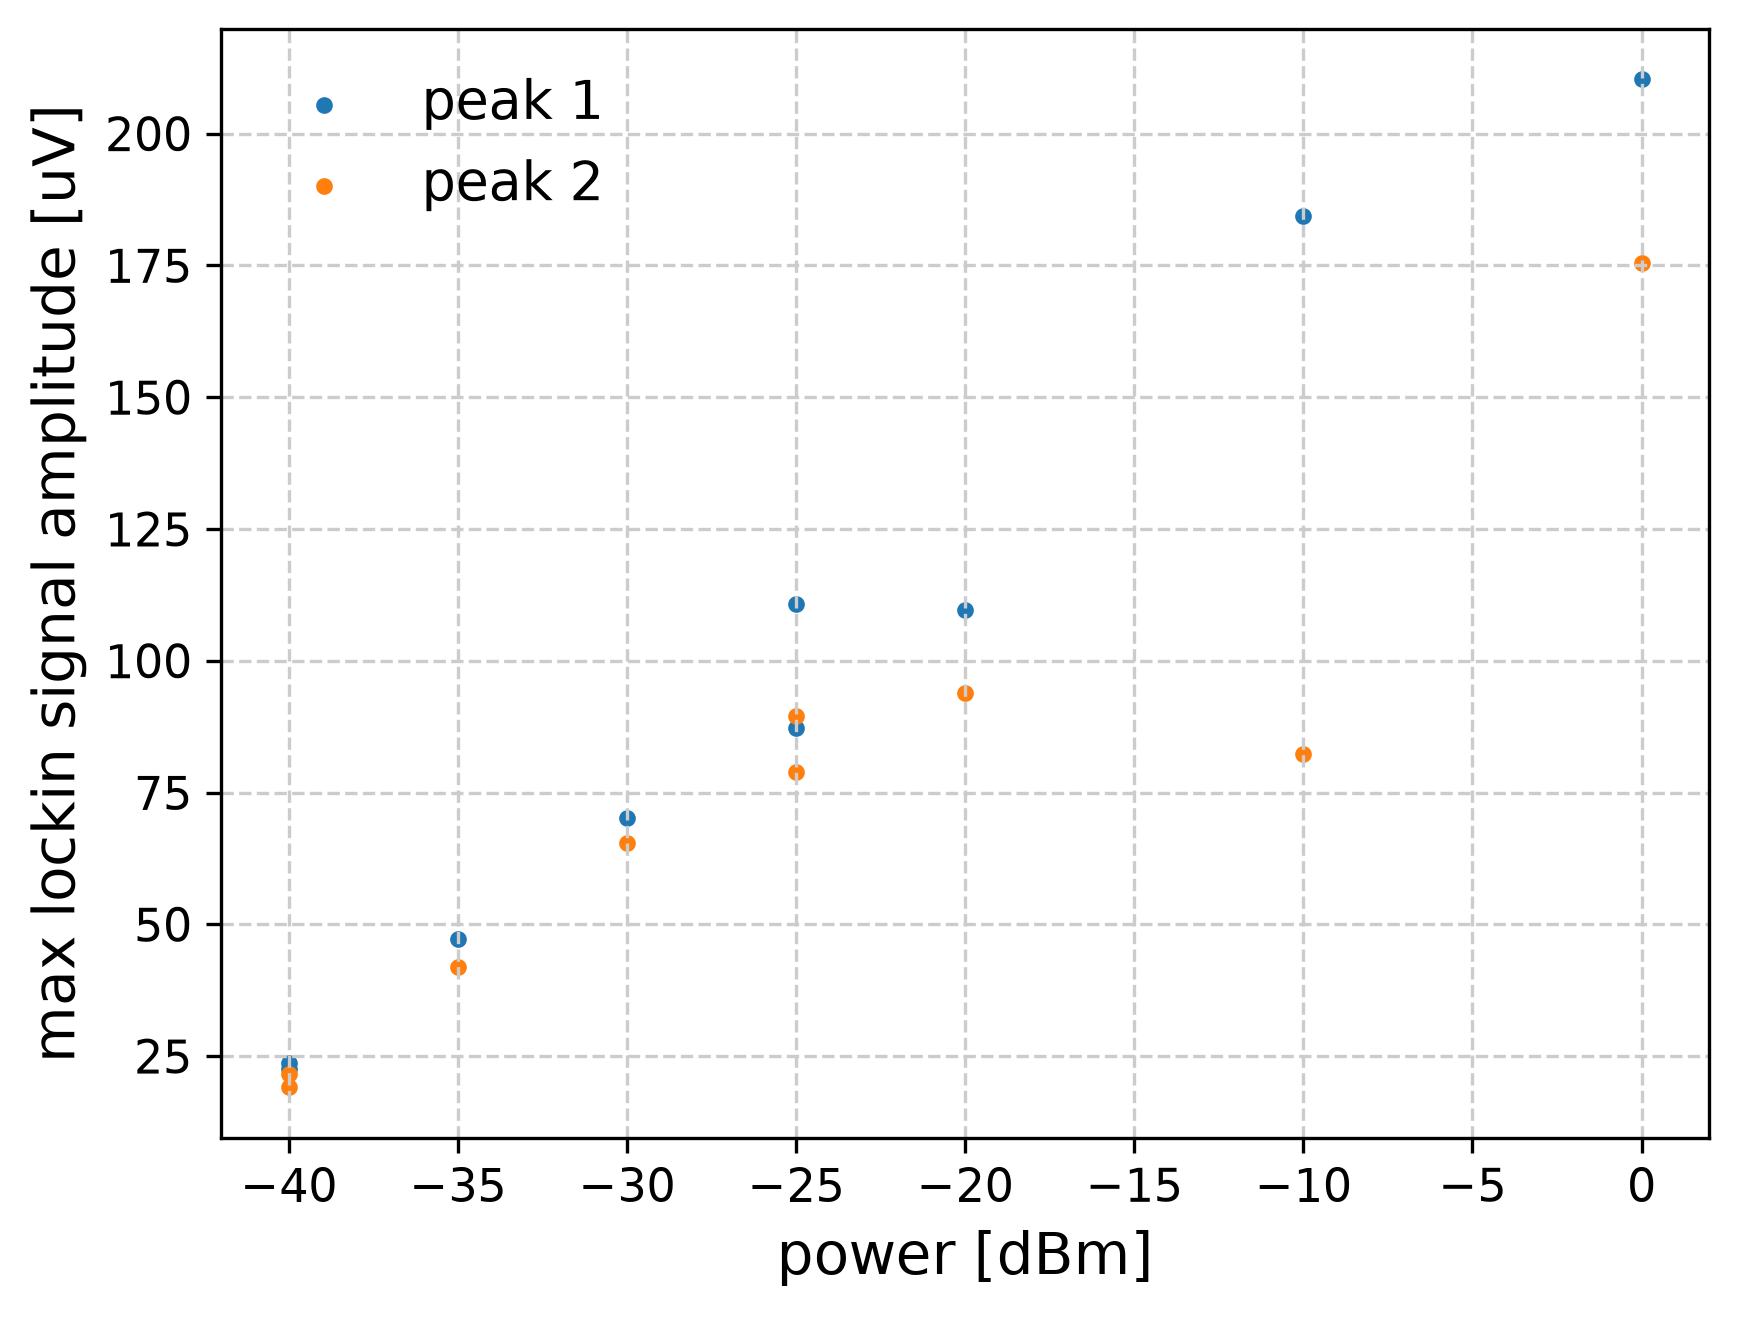

In [7]:
def peak_heights(popt):
    offset, amp1, _, _, amp2, _, _ = popt
    return offset + abs(amp1), offset + abs(amp2)


peak_heights_uv = np.array([peak_heights(fit["popt"]) for fit in tau_0p5_fits])

fig, ax = plt.subplots(dpi=300)
ax.scatter(powers_dbm, peak_heights_uv[:, 0], label="peak 1")
ax.scatter(powers_dbm, peak_heights_uv[:, 1], label="peak 2")
ax.set_xlabel("power [dBm]")
ax.set_ylabel("max lockin signal amplitude [uV]")
ax.legend()
plt.show()

## power = -25 dBm, various taus

`tau_scan_15` onwards changed the measurement setup slightly, so those runs
are kept in a separate set of plots rather than mixed in with `tau_scan_7`-`14`.

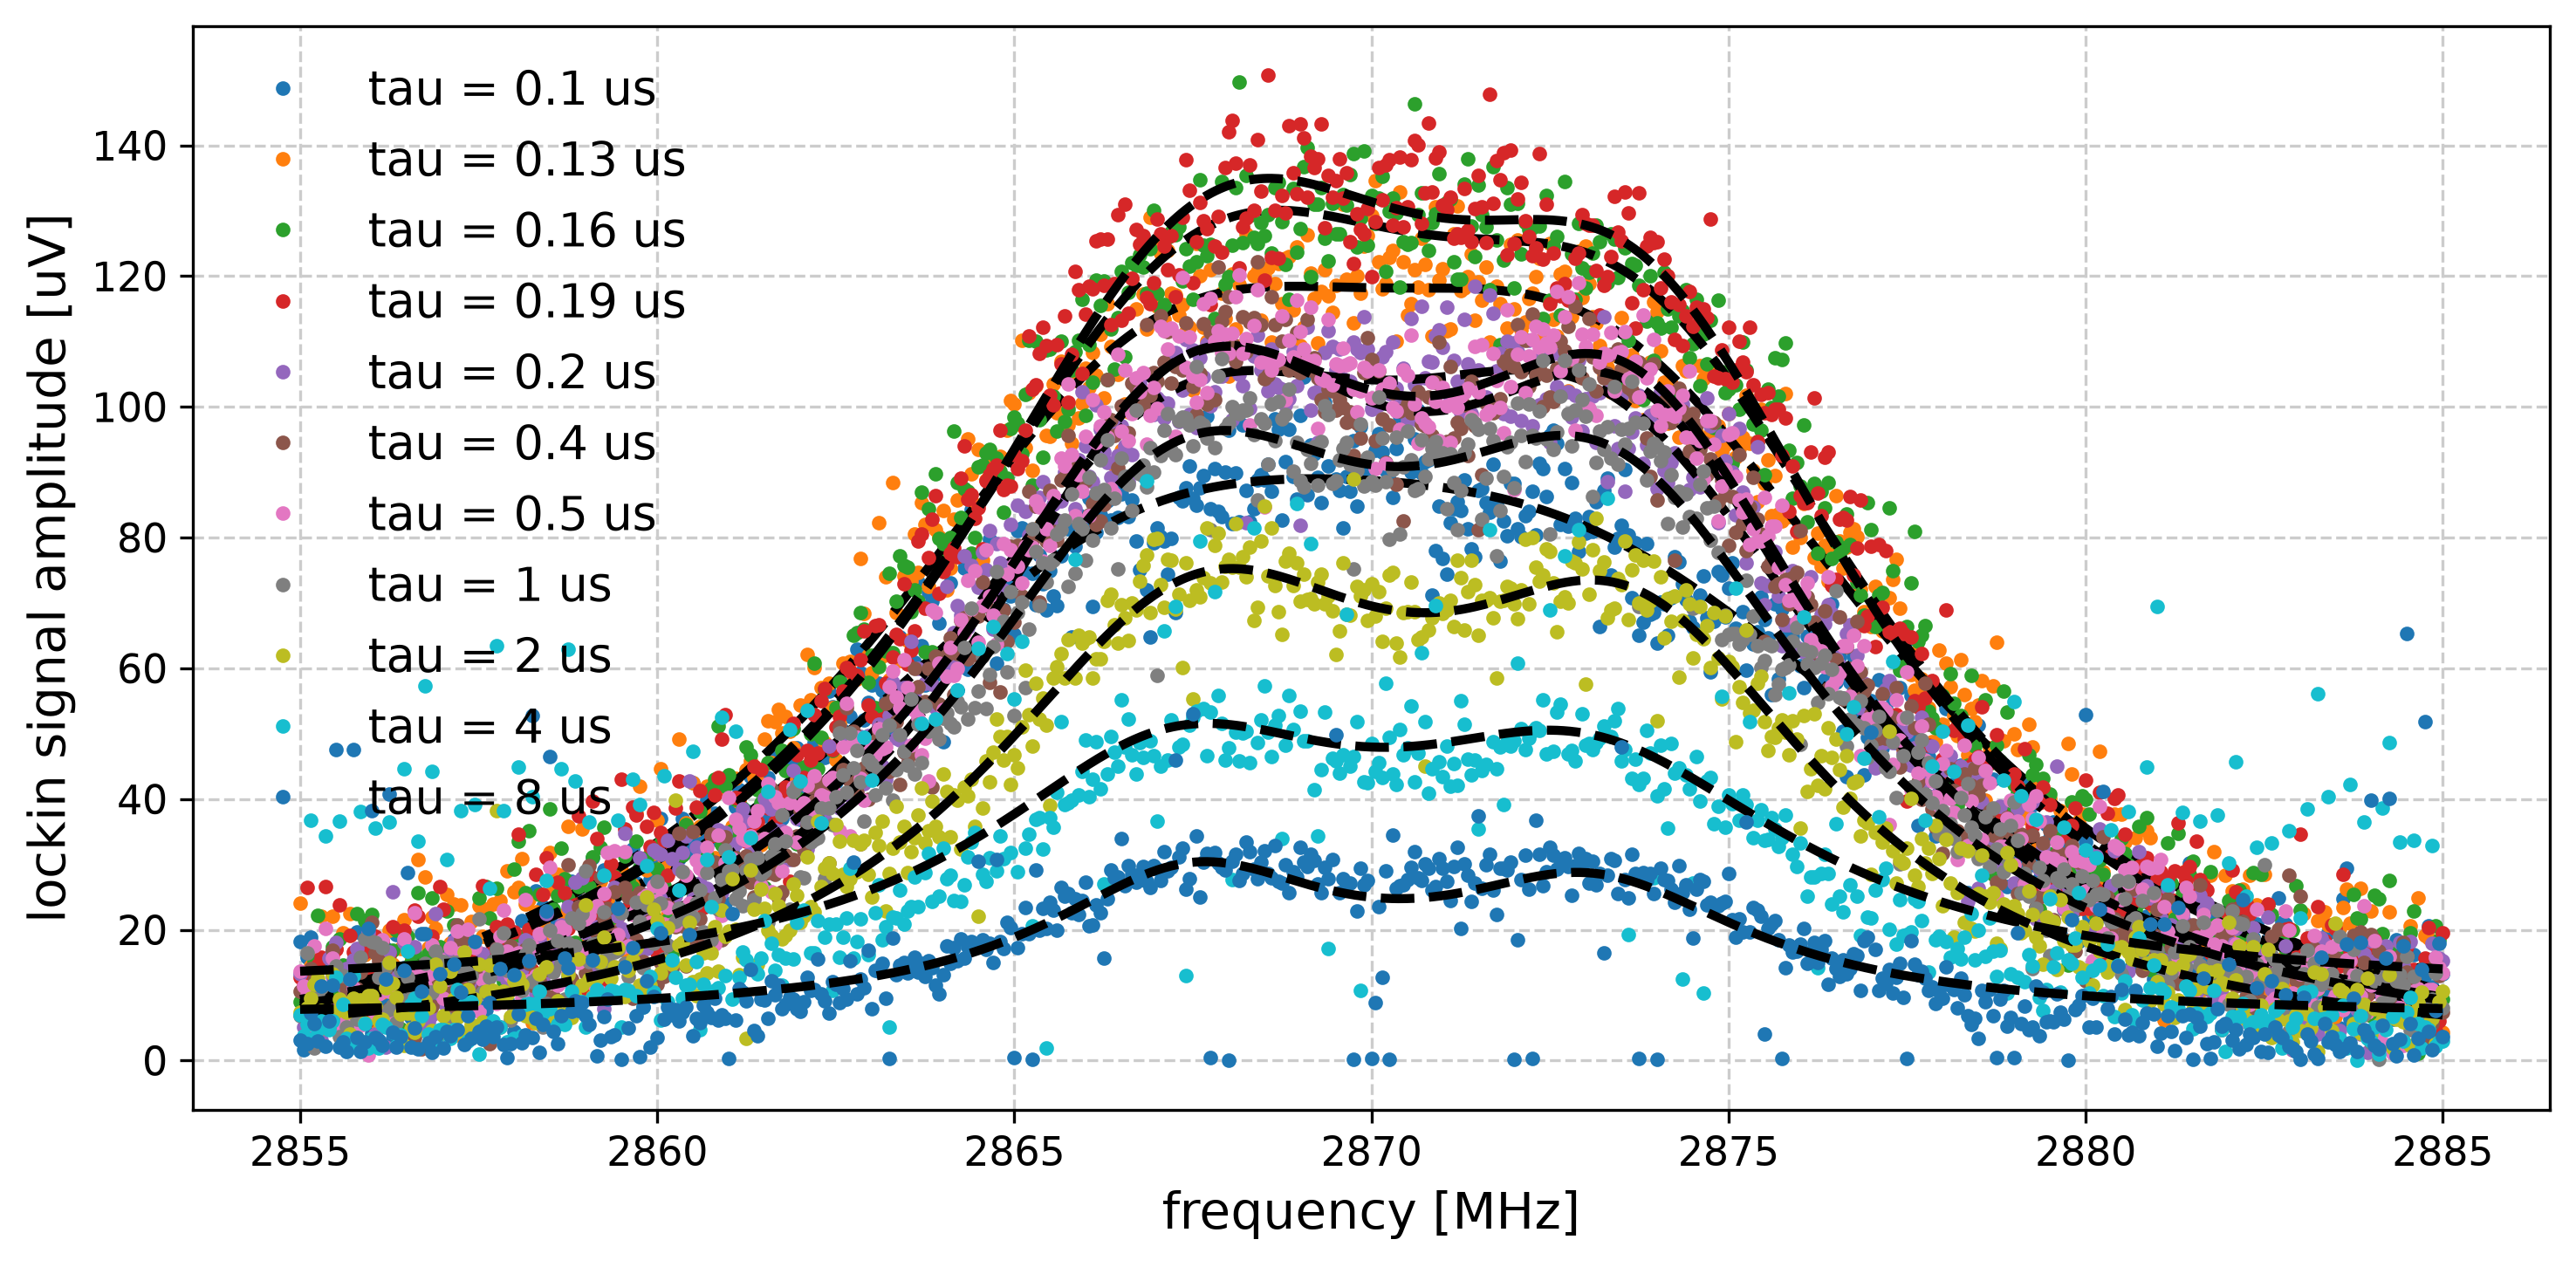

         label  FWHM 1 [MHz]  FWHM 2 [MHz]
  tau = 0.1 us        12.196        14.009
 tau = 0.13 us        10.618        10.841
 tau = 0.16 us        10.135         9.017
 tau = 0.19 us         9.639         8.142
  tau = 0.2 us         9.131         8.892
  tau = 0.4 us         7.724         7.288
  tau = 0.5 us         8.224         7.243
    tau = 1 us         7.914         7.639
    tau = 2 us         7.672         6.950
    tau = 4 us         6.680         7.328
    tau = 8 us         5.131         5.405


In [8]:
SETUP_CHANGE_SCAN_NUM = 15

power_m25_runs = sorted(
    (run for run in runs if run["power_dbm"] == -25.0 and run["scan_num"] < SETUP_CHANGE_SCAN_NUM),
    key=lambda run: run["tau_mw_us"],
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
power_m25_fits = plot_runs_with_fits(ax, power_m25_runs, lambda run: f"tau = {run['tau_mw_us']:g} us")
fig.tight_layout()
plt.show()

print_linewidths(power_m25_fits, lambda run: f"tau = {run['tau_mw_us']:g} us")

## power = -25 dBm, various taus (tau_scan_15 onwards, new setup)

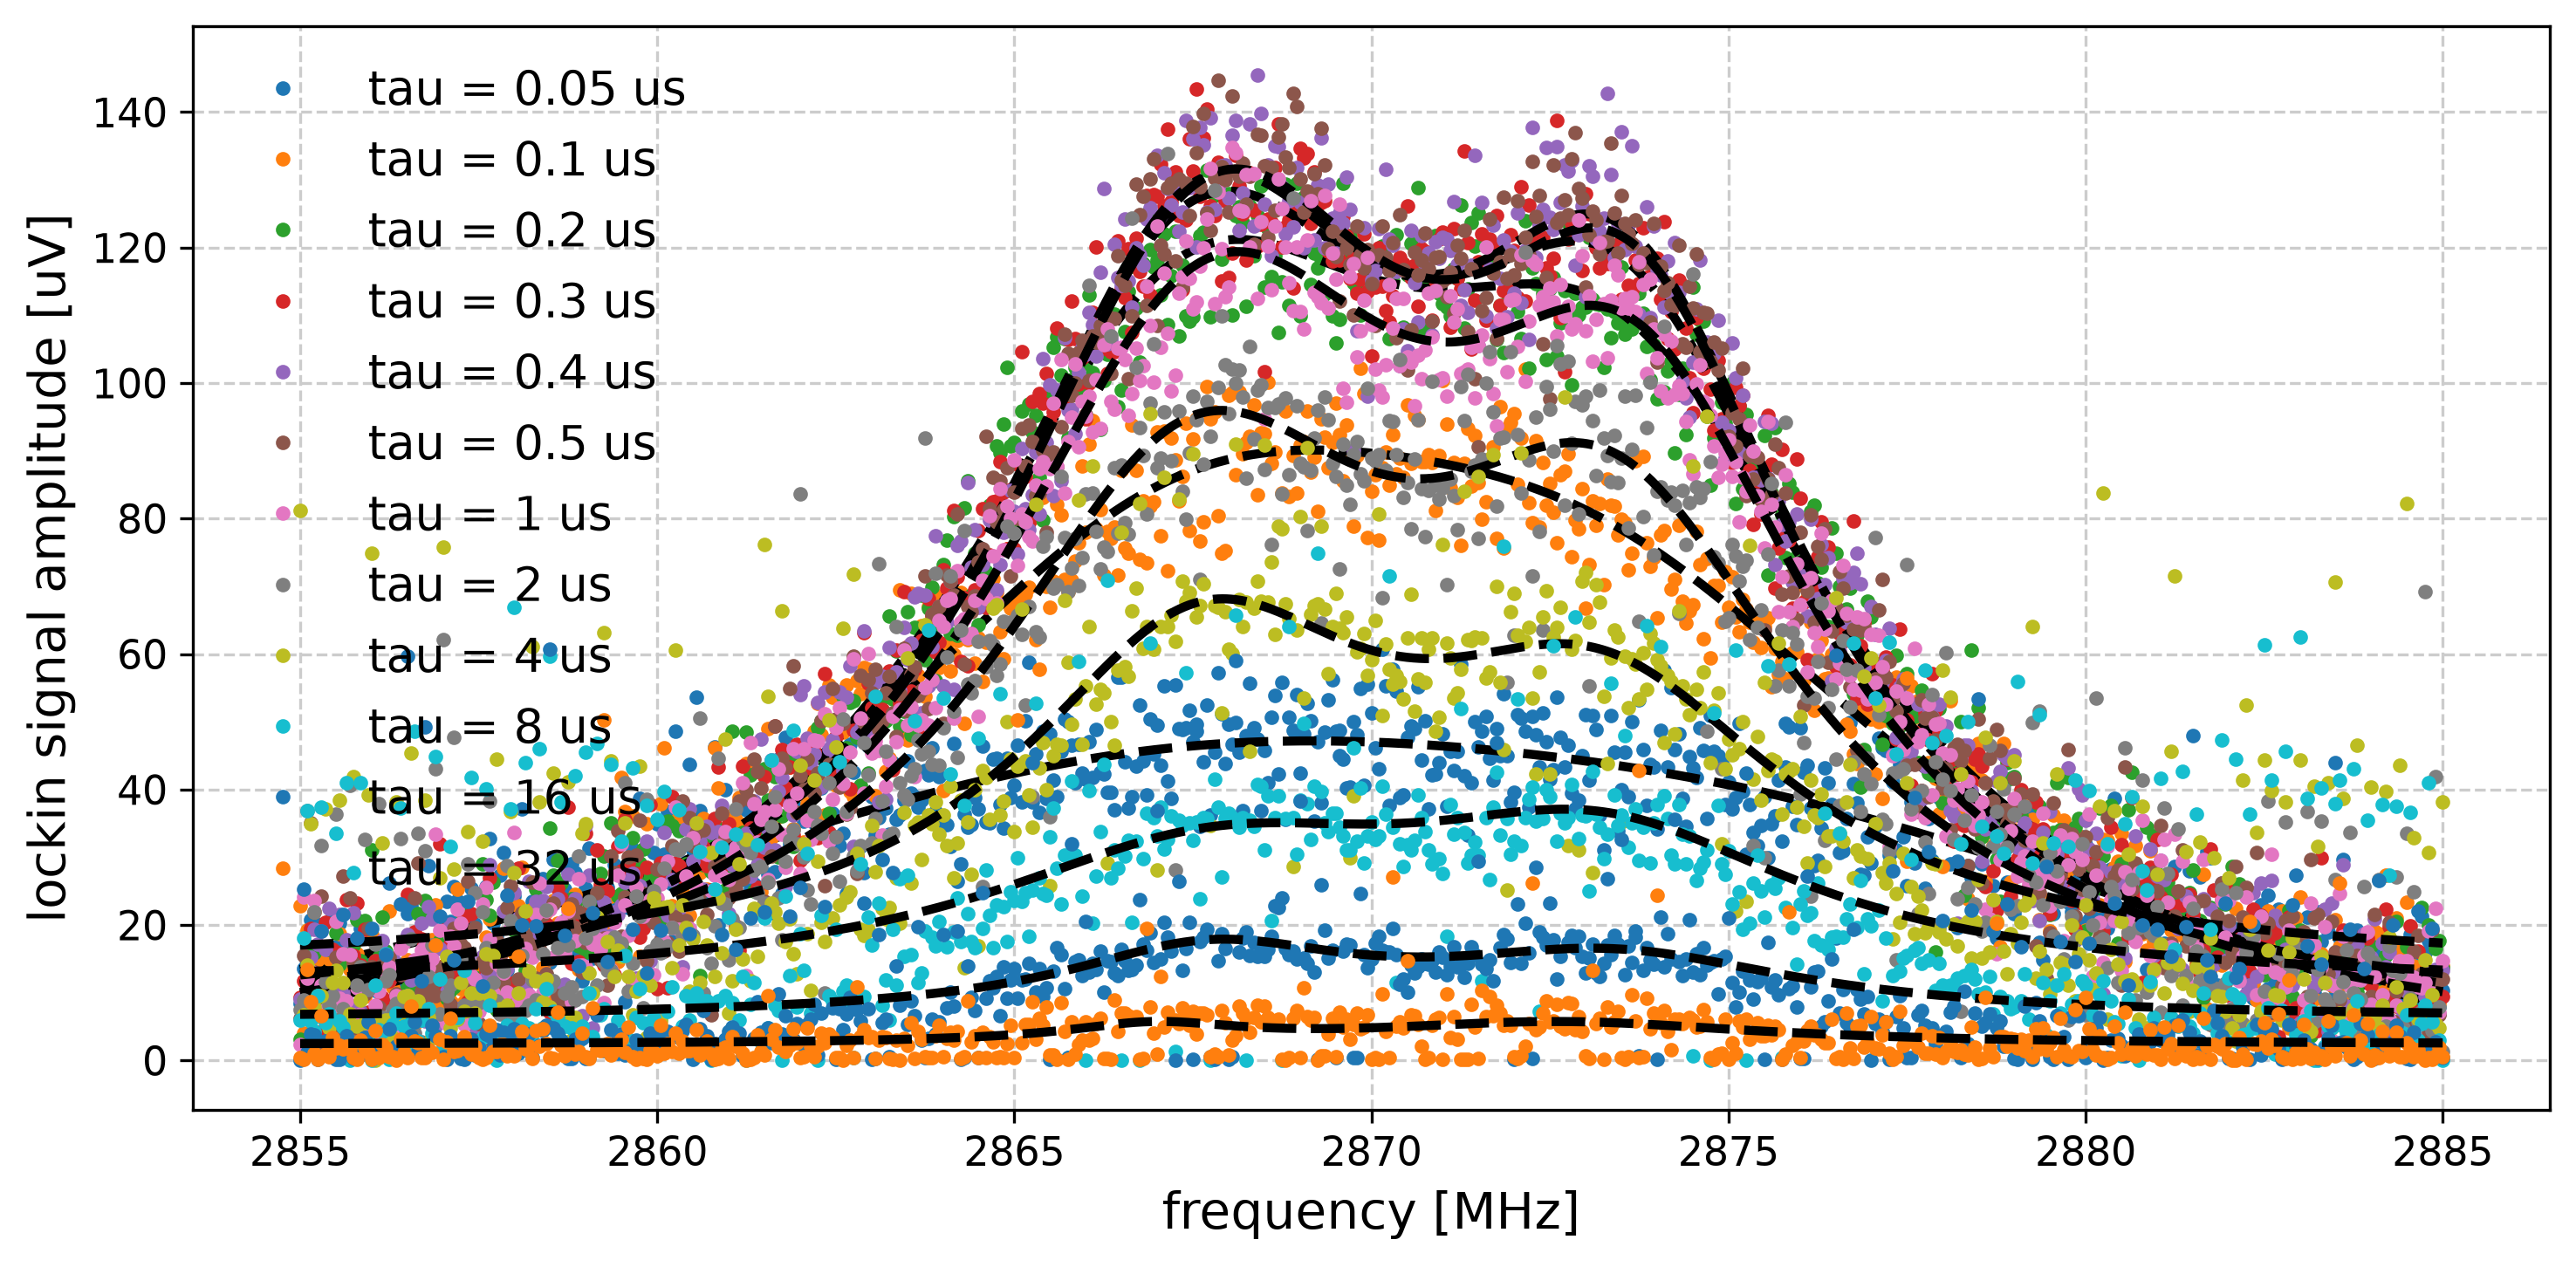

         label  FWHM 1 [MHz]  FWHM 2 [MHz]
 tau = 0.05 us        24.335        16.709
  tau = 0.1 us        12.122        12.369
  tau = 0.2 us         8.463         8.302
  tau = 0.3 us         7.681         6.953
  tau = 0.4 us         7.332         6.487
  tau = 0.5 us         7.433         6.299
    tau = 1 us         7.731         6.616
    tau = 2 us         7.176         6.709
    tau = 4 us         6.229         6.609
    tau = 8 us         7.845         6.977
   tau = 16 us         4.994         6.392
   tau = 32 us         2.990         6.739


In [9]:
power_m25_runs_new = sorted(
    (run for run in runs if run["power_dbm"] == -25.0 and run["scan_num"] >= SETUP_CHANGE_SCAN_NUM),
    key=lambda run: run["tau_mw_us"],
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
power_m25_fits_new = plot_runs_with_fits(ax, power_m25_runs_new, lambda run: f"tau = {run['tau_mw_us']:g} us")
fig.tight_layout()
plt.show()

print_linewidths(power_m25_fits_new, lambda run: f"tau = {run['tau_mw_us']:g} us")

## Tau vs. linewidth

Averaged over the two peaks (mean +/- SEM). The dashed curve is the Fourier
transform limit, 0.8 / tau_mw_us. The dotted line is the T2*-limited
linewidth, 1 / (pi * T2*).

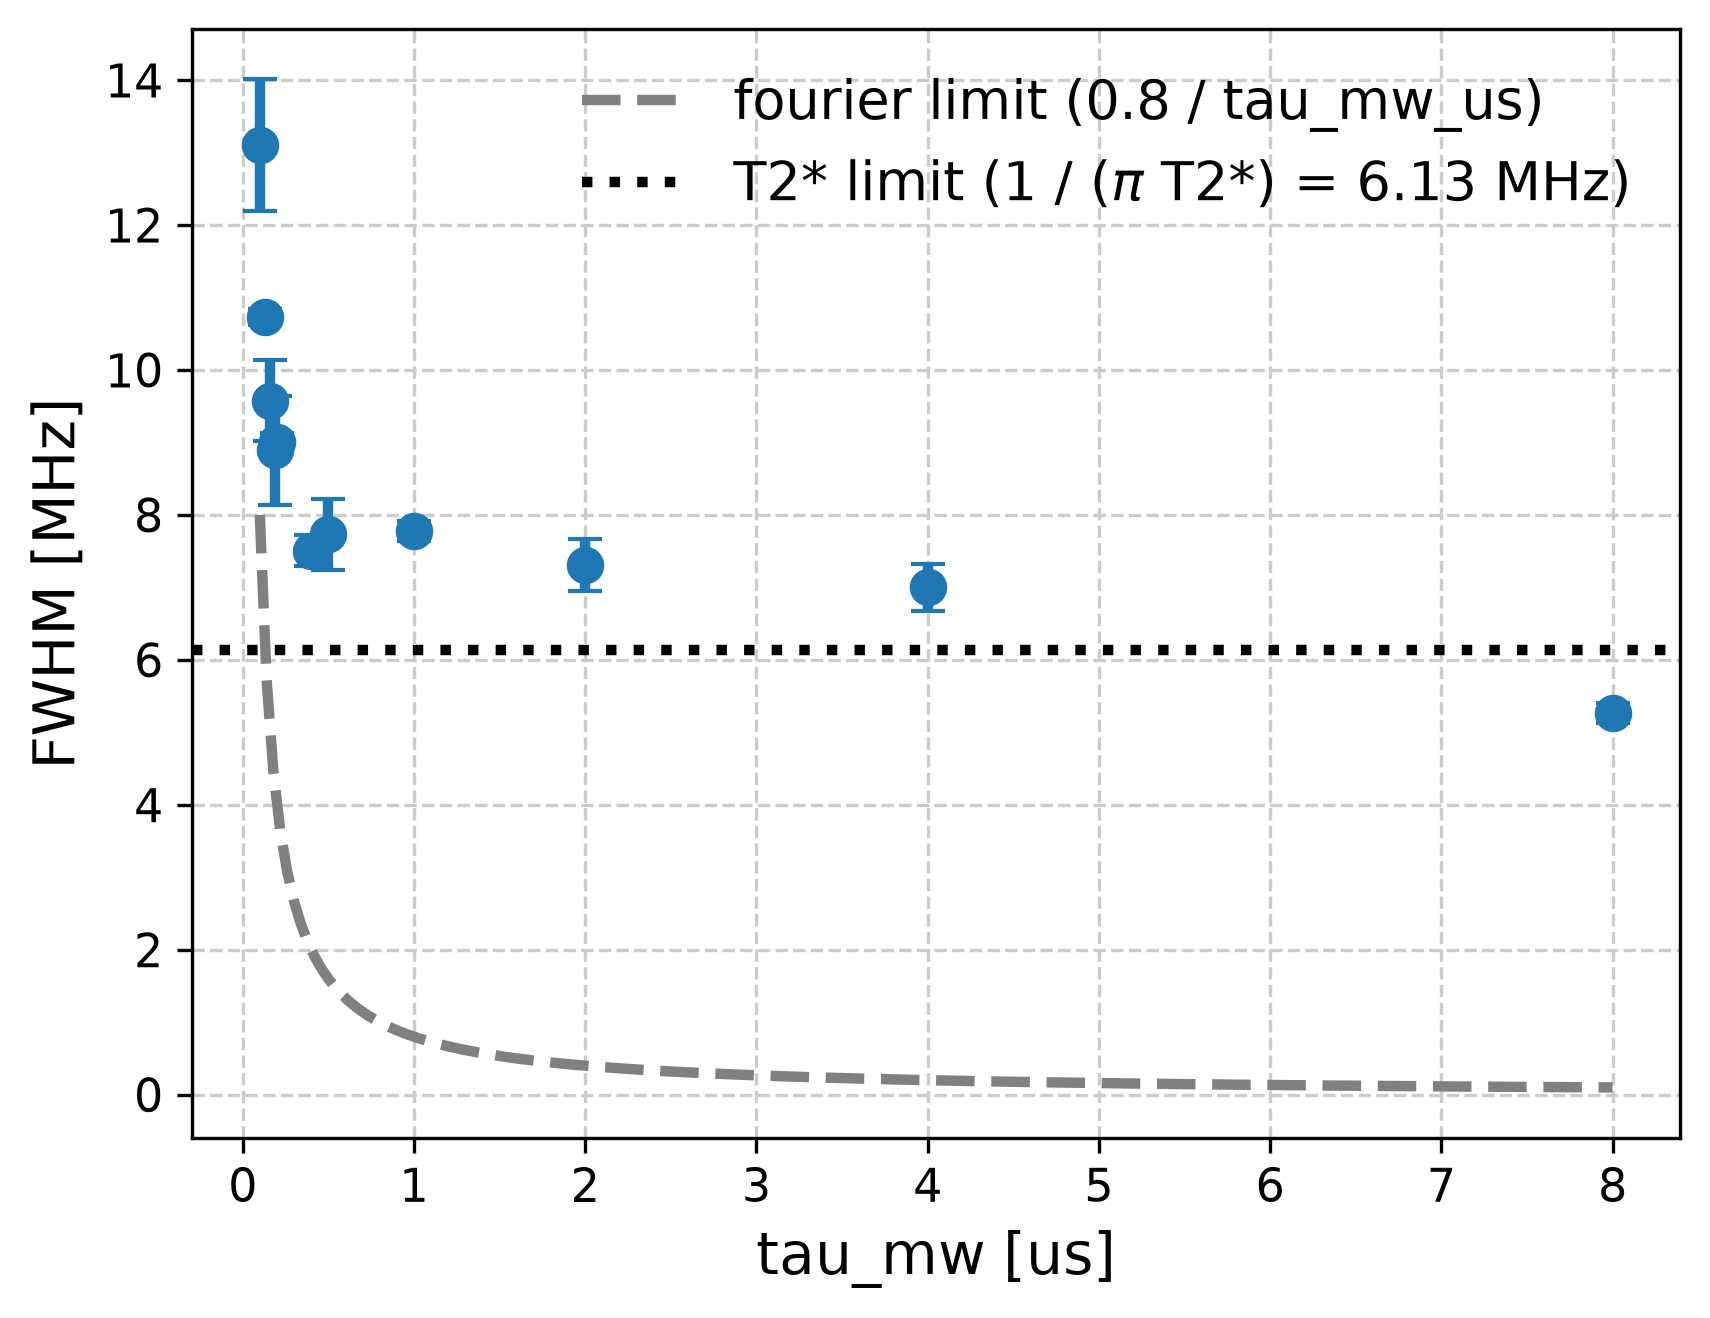

In [10]:
T2_STAR_US = 51.9e-3
T2_STAR_LIMIT_MHZ = 1 / (np.pi * T2_STAR_US)


def plot_tau_vs_linewidth(ax, fits, xscale="linear"):
    taus_us = np.array([fit["tau_mw_us"] for fit in fits])
    fwhm_pairs = np.array(
        [[2 * abs(fit["popt"][3]), 2 * abs(fit["popt"][6])] for fit in fits]
    )
    fwhm_mean, fwhm_sem = mean_and_sem(fwhm_pairs, axis=1)

    if xscale == "log":
        taus_dense_us = np.logspace(np.log10(taus_us.min()), np.log10(taus_us.max()), 200)
    else:
        taus_dense_us = np.linspace(taus_us.min(), taus_us.max(), 200)

    ax.errorbar(taus_us, fwhm_mean, yerr=fwhm_sem, fmt="o", markersize=8, capsize=4)
    ax.plot(taus_dense_us, 0.8 / taus_dense_us, linestyle="--", color="gray", label="fourier limit (0.8 / tau_mw_us)")
    ax.axhline(
        T2_STAR_LIMIT_MHZ, linestyle=":", color="black",
        label=f"T2* limit (1 / ($\\pi$ T2*) = {T2_STAR_LIMIT_MHZ:.2f} MHz)",
    )
    ax.set_xscale(xscale)
    ax.set_xlabel("tau_mw [us]")
    ax.set_ylabel("FWHM [MHz]")
    ax.legend()
    return taus_us


fig, ax = plt.subplots(dpi=300)
taus_us = plot_tau_vs_linewidth(ax, power_m25_fits)
plt.show()

## Tau vs. linewidth (tau_scan_15 onwards, new setup)

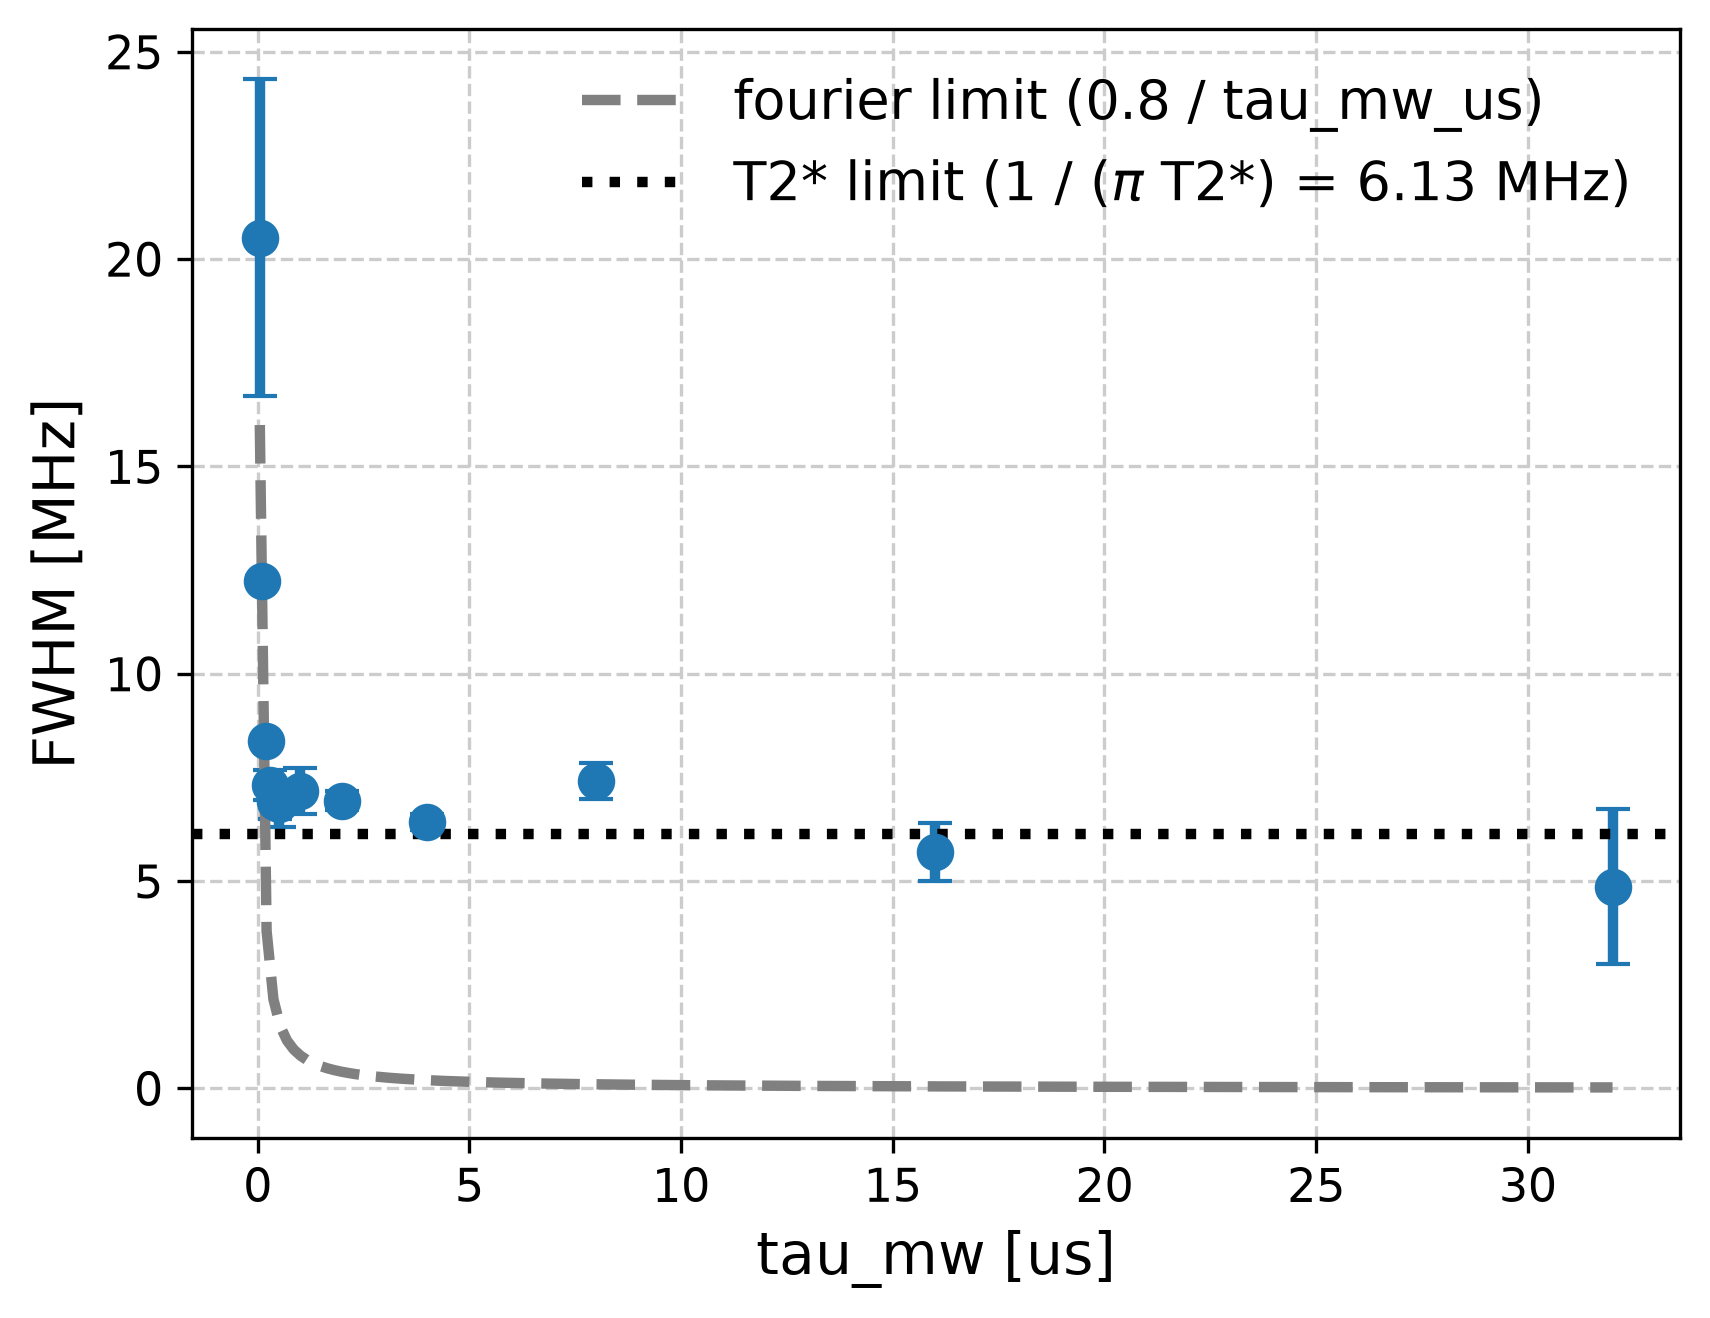

In [11]:
fig, ax = plt.subplots(dpi=300)
taus_us_new = plot_tau_vs_linewidth(ax, power_m25_fits_new)
plt.show()

## Tau vs. max signal

Peak height (offset + amplitude) for each of the two fitted peaks.

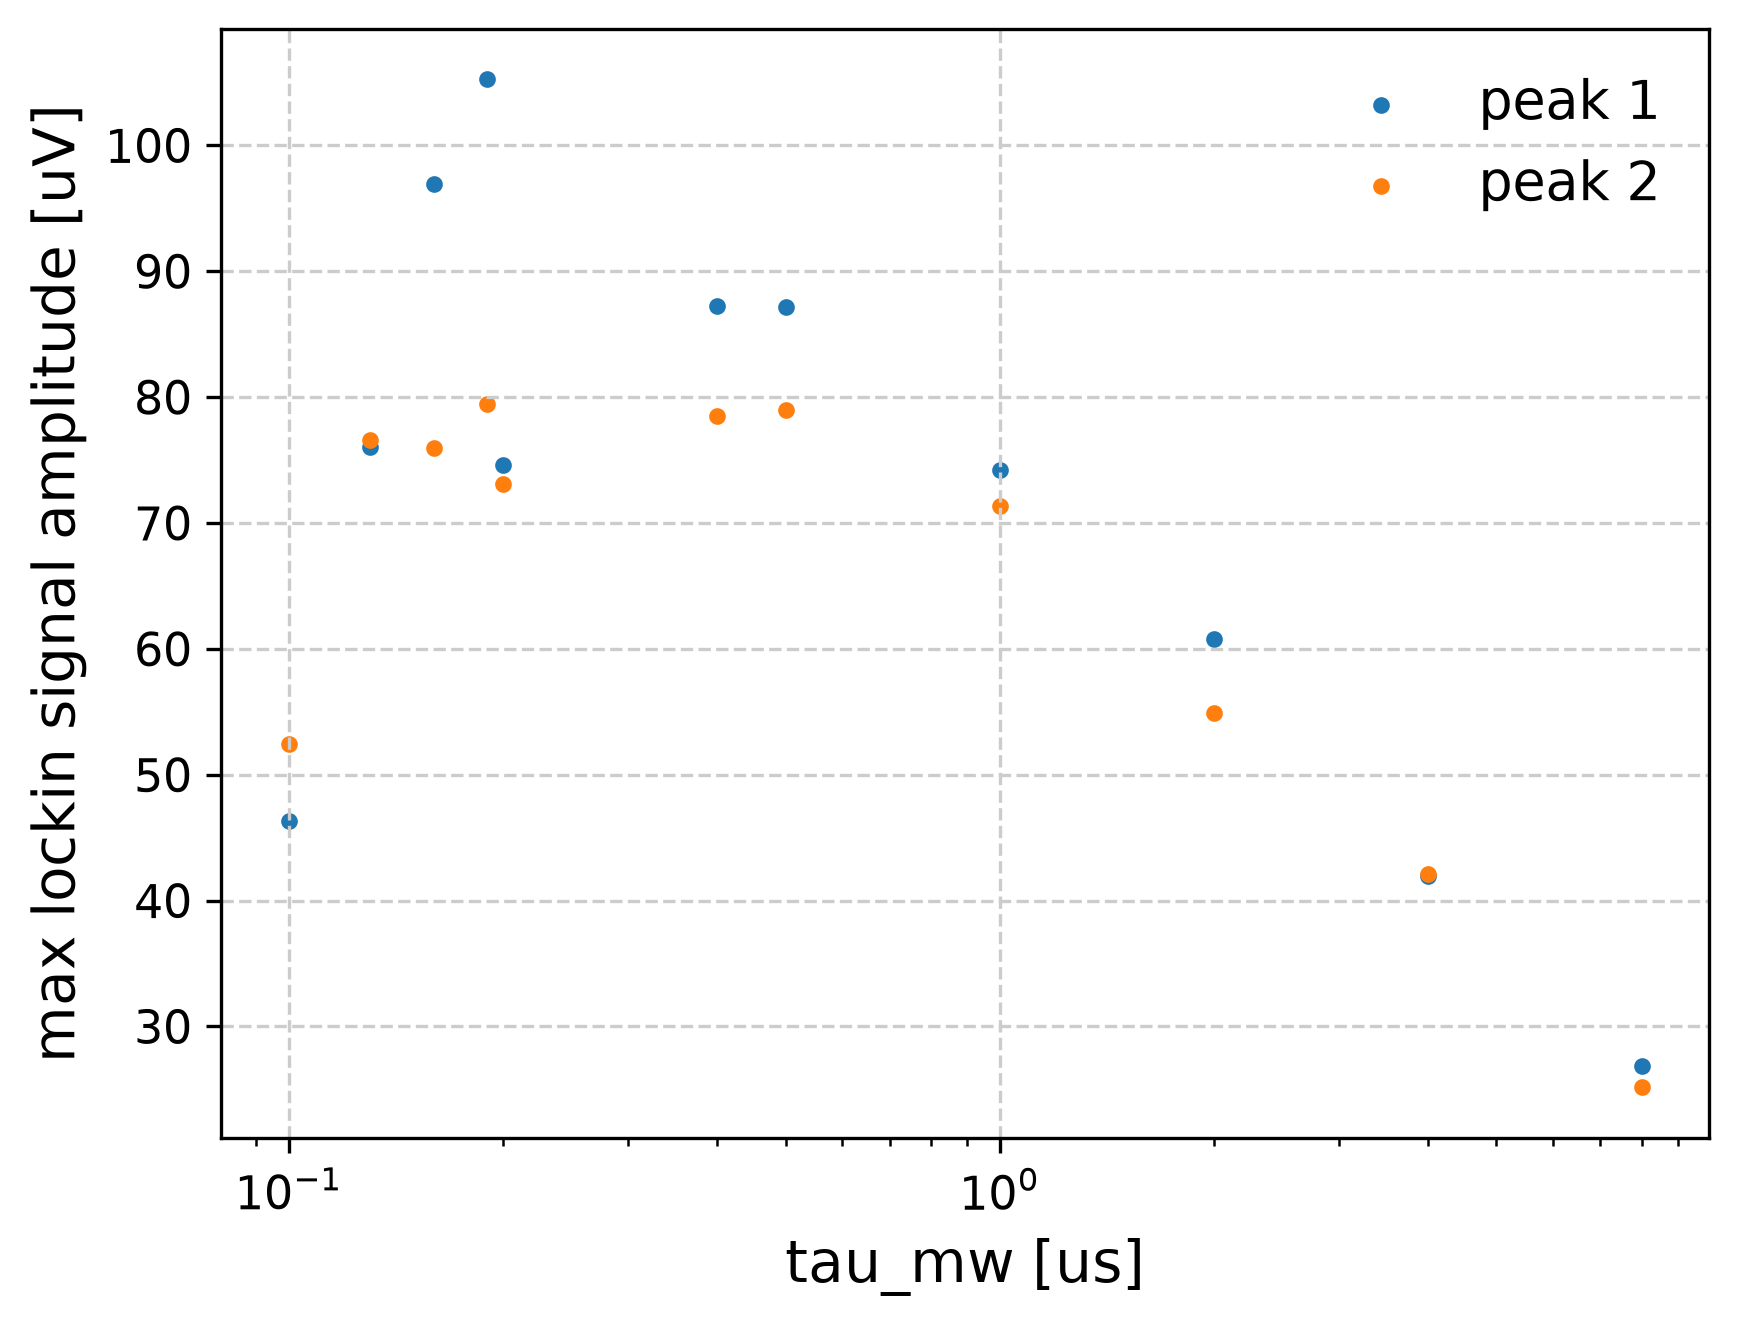

In [12]:
def plot_tau_vs_max_signal(ax, fits, taus_us, xscale="linear"):
    peak_heights_uv = np.array([peak_heights(fit["popt"]) for fit in fits])
    ax.scatter(taus_us, peak_heights_uv[:, 0], label="peak 1")
    ax.scatter(taus_us, peak_heights_uv[:, 1], label="peak 2")
    ax.set_xscale(xscale)
    ax.set_xlabel("tau_mw [us]")
    ax.set_ylabel("max lockin signal amplitude [uV]")
    ax.legend()


fig, ax = plt.subplots(dpi=300)
plot_tau_vs_max_signal(ax, power_m25_fits, taus_us, xscale="log")
plt.show()

## Tau vs. max signal (tau_scan_15 onwards, new setup)

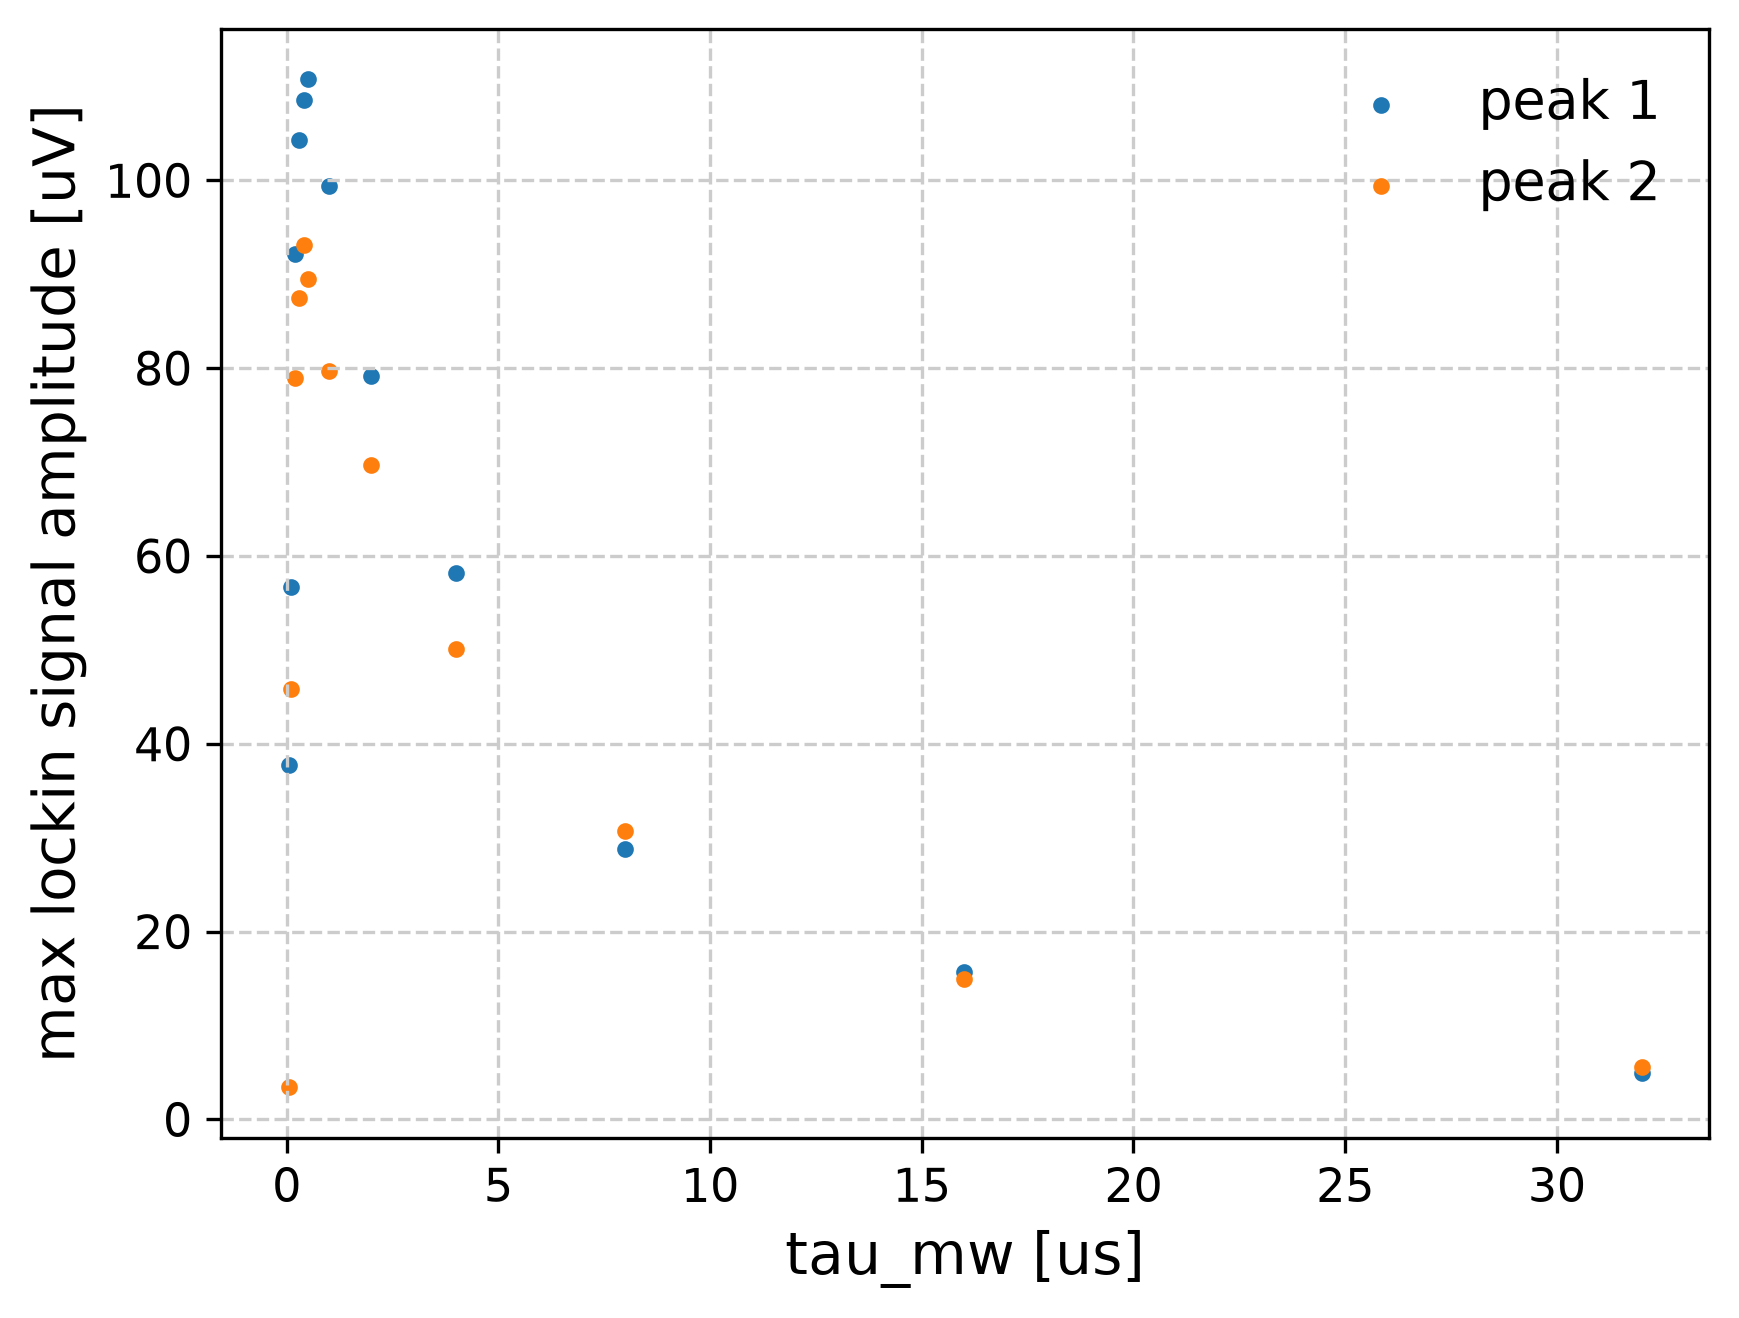

In [13]:
fig, ax = plt.subplots(dpi=300)
plot_tau_vs_max_signal(ax, power_m25_fits_new, taus_us_new)
plt.show()